# Population of GRB

## Generation for lognormal distribution

In [5]:
import numpy as np
from scipy.stats import lognorm

from scipy.stats import truncnorm

def generate_lognormal_population(size, mean, sigma, min_value, max_value, random_state=None):
    rng = np.random.default_rng(random_state)
    # Conversion log10
    a = (np.log10(min_value) - mean) / sigma
    b = (np.log10(max_value) - mean) / sigma
    samples_log = truncnorm.rvs(a, b, loc=mean, scale=sigma, size=size, random_state=rng)
    samples = 10 ** samples_log
    return samples

In [6]:
import numpy as np

def generate_T90_population(size, params, min_value=None, max_value=None, random_state=None):
    """
    Génère une population de T90 selon un mélange de deux gaussiennes en log(T90).
    
    Args:
        size (int): Nombre d'éléments à générer.
        params (dict): Dictionnaire avec les clés 'mu1', 'sigma1', 'w1', 'mu2', 'sigma2', 'w2'.
        min_value (float, optional): Valeur minimale de T90.
        max_value (float, optional): Valeur maximale de T90.
        random_state (int, optional): Graine aléatoire.
        
    Returns:
        np.ndarray: Tableau des T90 générés.
    """
    rng = np.random.default_rng(random_state)
    n1 = int(size * params['w1'])
    n2 = size - n1
    logT90_1 = rng.normal(params['mu1'], params['sigma1'], n1)
    logT90_2 = rng.normal(params['mu2'], params['sigma2'], n2)
    T90 = np.concatenate([10**logT90_1, 10**logT90_2])
    if min_value is not None:
        T90 = T90[T90 >= min_value]
    if max_value is not None:
        T90 = T90[T90 <= max_value]
    # Si on a perdu des valeurs à cause du cut, on complète
    while len(T90) < size:
        missing = size - len(T90)
        n1 = int(missing * params['w1'])
        n2 = missing - n1
        logT90_1 = rng.normal(params['mu1'], params['sigma1'], n1)
        logT90_2 = rng.normal(params['mu2'], params['sigma2'], n2)
        new_T90 = np.concatenate([10**logT90_1, 10**logT90_2])
        if min_value is not None:
            new_T90 = new_T90[new_T90 >= min_value]
        if max_value is not None:
            new_T90 = new_T90[new_T90 <= max_value]
        T90 = np.concatenate([T90, new_T90])
    return T90[:size]




In [7]:
N = 10_000
# GRB Population
# E_grb
E_grb = generate_lognormal_population(size=N, mean=52, sigma=1., min_value=1e46, max_value=1e55, random_state=40)

# T_90
# Paramètres du tableau
params_T90 = {
    'mu1': 0.0208, 'sigma1': np.sqrt(0.367), 'w1': 0.245,
    'mu2': 1.476,  'sigma2': np.sqrt(0.189), 'w2': 0.755
}
T90 = generate_T90_population(
    size=N, params=params_T90, min_value=0.1, max_value=500, random_state=42
)

# Afterglow 
E_aft = generate_lognormal_population(size=N, mean=52, sigma=1., min_value=1e50, max_value=1e56, random_state=41)

t_dec = generate_lognormal_population(size=N, mean=np.log10(100), sigma=1., min_value=0.01, max_value=1000, random_state=42)
# t_break lognormal entre 0.1 et 10 jours (en secondes)
t_break = generate_lognormal_population(size=N, mean=np.log10(1*86400), sigma=1., min_value=0.1*86400, max_value=10*86400, random_state=43)

# distance 
d = generate_lognormal_population(size=N, mean=np.log10(1e9), sigma=1., min_value=40e6, max_value=1e10, random_state=44)

# angle theta uniform sur [0, pi/2]
theta = np.random.default_rng(45).uniform(0, np.pi/2, size=N)

# beta uniform sur [0.9, 1]

beta = np.random.default_rng(46).uniform(0.9, 1, size=N)

params = {
    'E_grb': E_grb,
    'T90': T90,
    'E_aft': E_aft, 
    't_dec': t_dec,
    't_break': t_break,
    'd': d,
    'theta': theta,
    'beta': beta
}

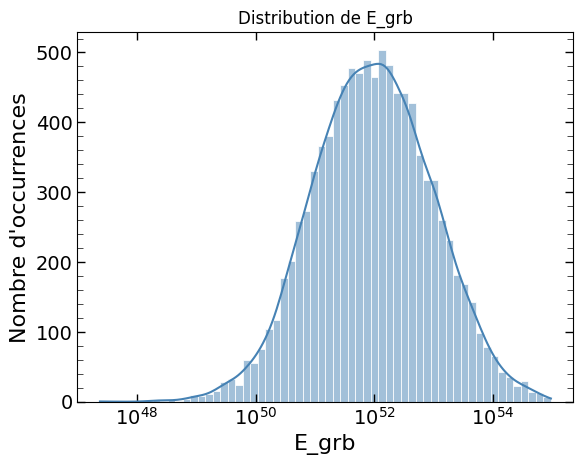

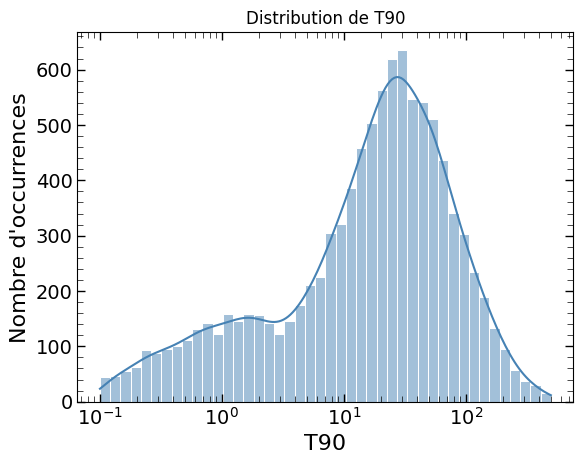

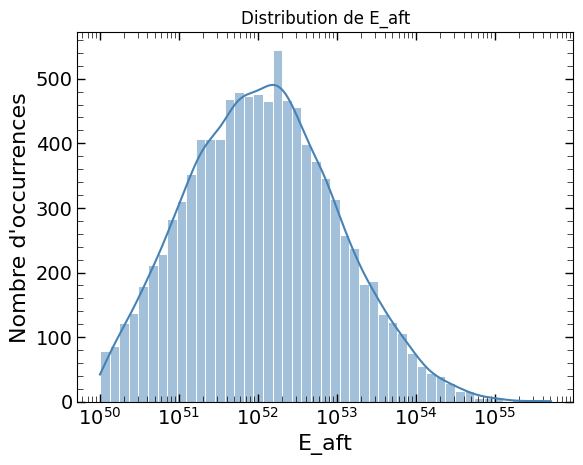

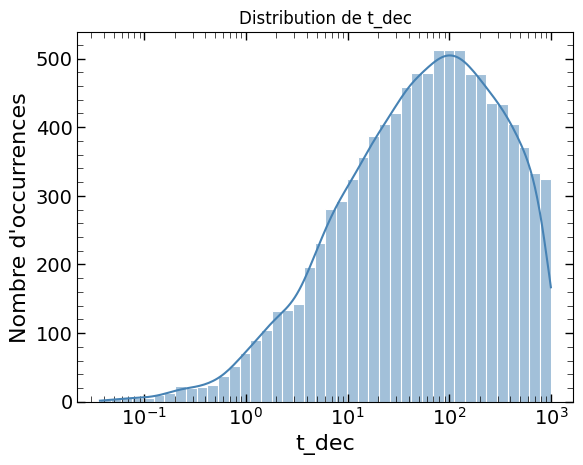

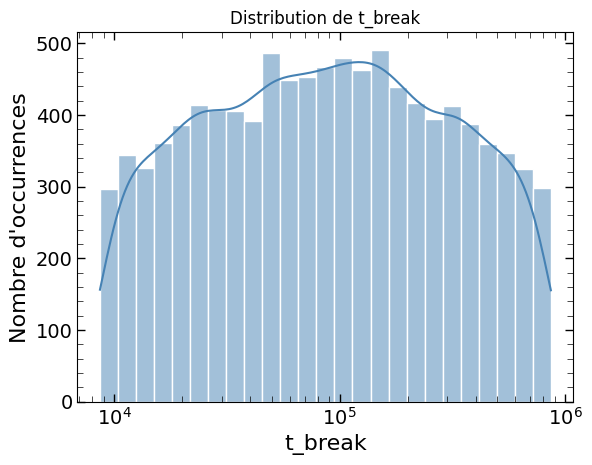

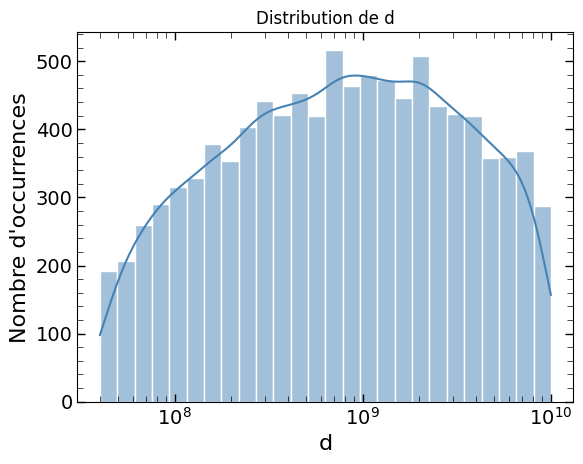

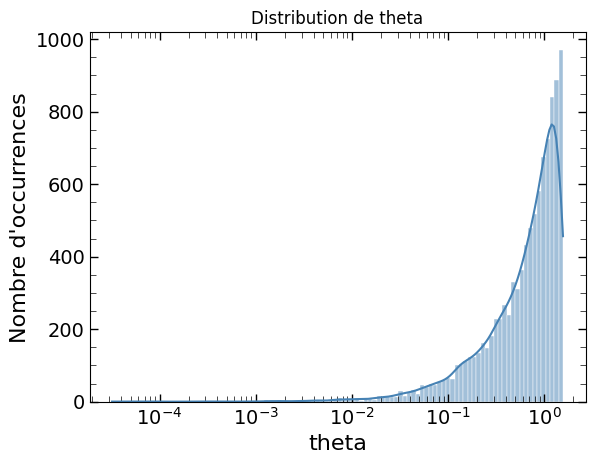

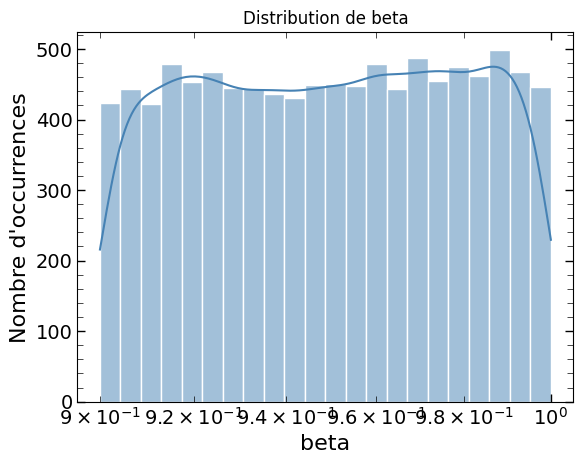

                 mean           std        median           min           max
E_grb    1.058502e+53  4.487202e+53  9.365454e+51  2.372670e+47  9.472922e+54
T90      3.725365e+01  5.184916e+01  2.042630e+01  1.003018e-01  4.956963e+02
E_aft    1.321488e+53  9.340973e+53  1.098981e+52  1.001751e+50  5.082702e+55
t_dec    1.604102e+02  2.196111e+02  6.254766e+01  3.672202e-02  9.998161e+02
t_break  1.731701e+05  1.991248e+05  8.792438e+04  8.643009e+03  8.633754e+05
d        1.786709e+09  2.240979e+09  7.875186e+08  4.000096e+07  9.997806e+09
theta    7.853205e-01  4.539553e-01  7.916700e-01  3.206145e-05  1.570726e+00
beta     9.497600e-01  2.886702e-02  9.498058e-01  9.000061e-01  9.999989e-01


In [8]:
# Plot des distributions
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

for key, values in params.items():
    plt.figure()
    sns.histplot(values, bins='auto', log_scale=(True, False), kde=True, color='steelblue', edgecolor='white')

    plt.title(f'Distribution de {key}')
    plt.xlabel(key)
    plt.ylabel("Nombre d'occurrences")
    plt.show()

# make a dataframe with the parameters mean, std, median, min, max
summary = {}
for key, values in params.items():
    summary[key] = {
        'mean': np.mean(values),
        'std': np.std(values),
        'median': np.median(values),
        'min': np.min(values),
        'max': np.max(values)
    }
summary_df = pd.DataFrame(summary).T
print(summary_df)

### Plot population 2D and KDE

In [13]:
def plot_2d_kde_population(pop_dict, x, y, bins=40, cmap="binary", alpha=0.5, xscale="linear", yscale="linear", save_kde_dir="grb_pop_kde2d"):
    from scipy.stats import gaussian_kde
    import numpy as np
    import matplotlib.pyplot as plt
    import os
    import joblib
    from matplotlib.gridspec import GridSpec

    xvals = np.asarray(pop_dict[x])
    yvals = np.asarray(pop_dict[y])
    mask = np.isfinite(xvals) & np.isfinite(yvals) & (xvals > 0) & (yvals > 0)
    xvals = xvals[mask]
    yvals = yvals[mask]

    if x =='d':
        xvals = xvals / 1e6  # convertir en Mpc
    if y =='d':
        yvals = yvals / 1e6  # convertir en Mpc
    if x == 'theta' or y == 'theta':
        xvals = np.rad2deg(xvals) if x == 'theta' else xvals
        yvals = np.rad2deg(yvals) if y == 'theta' else yvals
    if x =='t_break':
        xvals = xvals / 86400  # convertir en jours
    if y =='t_break':
        yvals = yvals / 86400  # convertir en jours
        
    #  Calculer la KDE en espace LOG si nécessaire
    x_for_kde = np.log10(xvals) if xscale == "log" else xvals
    y_for_kde = np.log10(yvals) if yscale == "log" else yvals
    # print min and max of x_for_kde and y_for_kde
    print(f"x_for_kde: min={x_for_kde.min()}, max={x_for_kde.max()}")
    print(f"y_for_kde: min={y_for_kde.min()}, max={y_for_kde.max()}")
    
    # Création de la grille pour l'évaluation (linéaire dans l'espace de la KDE)
    gx = np.linspace(x_for_kde.min(), x_for_kde.max(), 200)
    gy = np.linspace(y_for_kde.min(), y_for_kde.max(), 200)
    X_kde, Y_kde = np.meshgrid(gx, gy)
    
    positions = np.vstack([X_kde.ravel(), Y_kde.ravel()])
    values = np.vstack([x_for_kde, y_for_kde])
    
    kde = gaussian_kde(values, bw_method='silverman')
    Z = kde(positions).reshape(X_kde.shape)

    # Grille pour l'affichage (on repasse en linéaire pour pcolormesh si on utilise set_xscale('log'))
    X_plot = 10**X_kde if xscale == "log" else X_kde
    Y_plot = 10**Y_kde if yscale == "log" else Y_kde

    # --- Sauvegarde et niveaux (inchangé mais basé sur Z corrigé) ---
    os.makedirs(save_kde_dir, exist_ok=True)
    joblib.dump(kde, os.path.join(save_kde_dir, f"{x}_{y}_kde2d.joblib"))

    Z_flat = Z.flatten()
    Z_sorted = np.sort(Z_flat)[::-1]
    cumsum = np.cumsum(Z_sorted)
    cumsum /= cumsum[-1]
    
    def find_level(fraction):
        return Z_sorted[np.searchsorted(cumsum, fraction)]

    levels = [find_level(0.99), find_level(0.50), find_level(0.10)]

    # --- Visualisation ---
    fig = plt.figure(figsize=(8, 8))
    gs = GridSpec(2, 2, width_ratios=[7, 1.5], height_ratios=[1.5, 7], wspace=0.05, hspace=0.05)
    ax_joint = fig.add_subplot(gs[1, 0])
    ax_marg_x = fig.add_subplot(gs[0, 0], sharex=ax_joint)
    ax_marg_y = fig.add_subplot(gs[1, 1], sharey=ax_joint)

    # Fond de densité
    pcm = ax_joint.pcolormesh(X_plot, Y_plot, Z, cmap=cmap, shading="gouraud", alpha=alpha)
    
    # Contours (apparaîtront maintenant comme des ellipses)
    ax_joint.contour(X_plot, Y_plot, Z, levels=levels, colors=['blue', 'green', 'red'], linewidths=2)

    # Marges et échelles
    ax_joint.set_xscale(xscale)
    ax_joint.set_yscale(yscale)
    
    if xscale == "log":
        ax_marg_x.hist(xvals, bins=np.logspace(np.log10(xvals.min()), np.log10(xvals.max()), bins), color="#383C65")
        ax_marg_x.set_xscale("log")
    else:
        ax_marg_x.hist(xvals, bins=bins, color="#383C65")

    if yscale == "log":
        ax_marg_y.hist(yvals, bins=np.logspace(np.log10(yvals.min()), np.log10(yvals.max()), bins), orientation="horizontal", color="#383C65")
        ax_marg_y.set_yscale("log")
    else:
        ax_marg_y.hist(yvals, bins=bins, orientation="horizontal", color="#383C65")

    ax_joint.set_xlabel(x)
    ax_joint.set_ylabel(y)
    plt.show()

x_for_kde: min=-0.9998487808089062, max=0.9996859342005643
y_for_kde: min=50.0007596966569, max=55.70609464959999


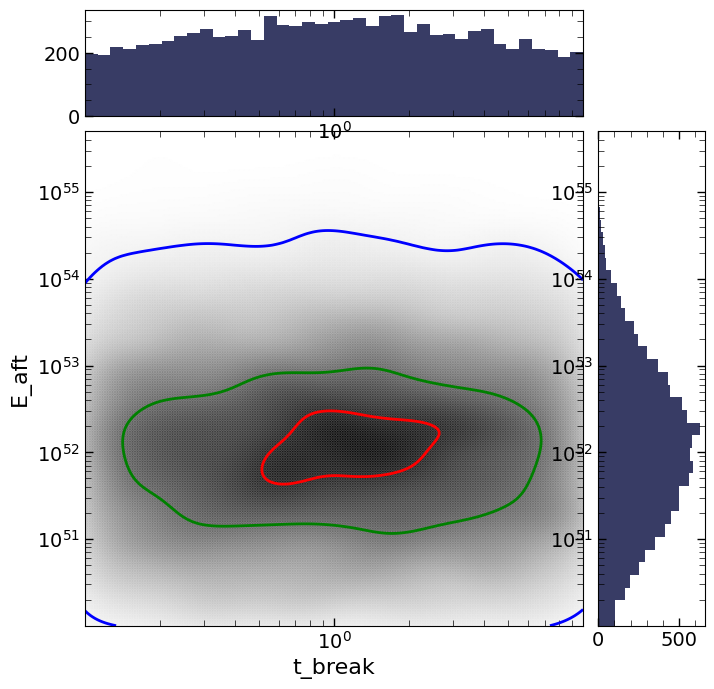

In [14]:
plot_2d_kde_population(params, x="t_break", y="E_aft", xscale="log", yscale="log")

In [9]:
import numpy as np
import pandas as pd

# Si tu as encore accès à tes données d'origine :
t_break = params["t_break"]  # ou df["t_break"]
E_aft = params["E_aft"]

print("log10(t_break):", np.log10(t_break).min(), np.log10(t_break).max())
print("log10(E_aft):", np.log10(E_aft).min(), np.log10(E_aft).max())

log10(t_break): 3.936664961669987 5.936199676679458
log10(E_aft): 50.0007596966569 55.70609464959999


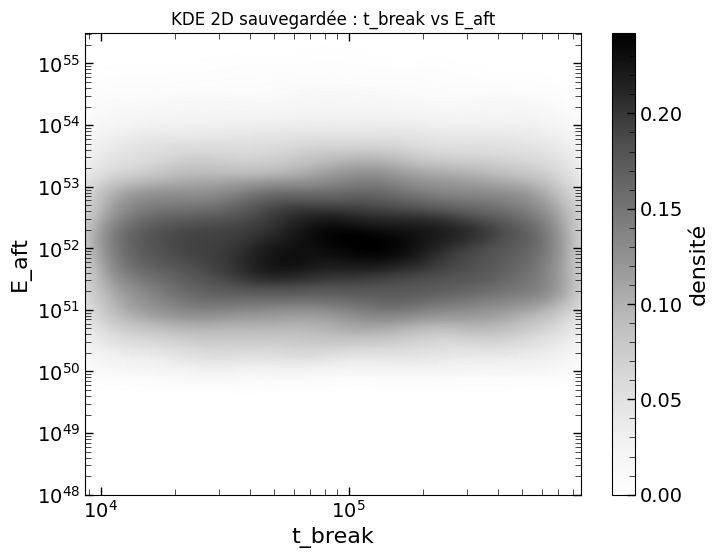

In [10]:
import joblib
import numpy as np
import matplotlib.pyplot as plt

x = "t_break"
y = "E_aft"
save_kde_dir = "grb_pop_kde2d"

# Charger la KDE
kde = joblib.load(f"{save_kde_dir}/{x}_{y}_kde2d.joblib")

# Définir la grille (adapter les bornes à ton cas)
# Ici, on prend un exemple de bornes typiques pour E_aft et E_grb
x_min, x_max = np.log10(t_break).min(), np.log10(t_break).max()
y_min, y_max = 48, 55.5  # log10(E_grb)
gx = np.linspace(x_min, x_max, 500)
gy = np.linspace(y_min, y_max, 500)
X, Y = np.meshgrid(gx, gy)
positions = np.vstack([X.ravel(), Y.ravel()])

# Évaluer la densité KDE
Z = kde(positions).reshape(X.shape)

# Affichage
plt.figure(figsize=(8, 6))
plt.pcolormesh(10**X, 10**Y, Z, shading="gouraud", cmap="Greys")
plt.xscale("log")
plt.yscale("log")
plt.xlabel(x)
plt.ylabel(y)
plt.title(f"KDE 2D sauvegardée : {x} vs {y}")
plt.colorbar(label="densité")
plt.show()

### SNR computation with LISA

In [25]:
from scipy.interpolate import interp1d
def compute_snr(f_signal, h_c, f_noise, h_n):
    f_signal = np.array(f_signal)
    h_c = np.array(h_c)
    f_noise = np.array(f_noise)
    h_n = np.array(h_n)

    interp_hn = interp1d(f_noise, h_n, kind='linear', bounds_error=False)
    h_n_interp = interp_hn(f_signal)
    
    # we compute the snr only for freq between 5e-6 and 1e-1 Hz to avoid issues with extrapolation
    # and we are still in the LISA freq band 
    mask = (f_signal >= 5e-5) & (f_signal <= 1e-1)
    f_signal = f_signal[mask]
    h_c = h_c[mask]
    h_n_interp = h_n_interp[mask]

    integrand = (h_c**2) / (h_n_interp**2)
    snr_squared = np.trapezoid(integrand, x=np.log(f_signal))
    snr = np.sqrt(snr_squared)
    return snr

In [38]:
from scipy.stats import qmc
import numpy as np
import pandas as pd

def generate_population_quasi_mc(n_samples, seed=42):
    bounds_log = [
        (46, 55),                # log10(E_GRB)
        (np.log10(0.1), np.log10(500)),   # log10(T_90)
        (50, 56),                # log10(E_aft)
        (np.log10(0.01), np.log10(1000)), # log10(t_dec)
        (np.log10(0.1*86400), np.log10(10*86400)), # log10(t_jet_break)
        (np.log10(40e6), np.log10(1e10)), # log10(d)
        (0, np.log10(np.pi/2)),            # log10(theta) 
        (np.log10(0.9), np.log10(1.0))     # log10(beta)
    ]
    param_names = ['E_GRB', 'T_90', 'E_aft', 't_dec', 't_jet_break', 'd', 'theta', 'beta']
    n_dim = len(bounds_log)
    sampler = qmc.Sobol(d=n_dim, scramble=True, seed=seed)
    sample_unit = sampler.random(n=n_samples)
    l_bounds = np.array([b[0] for b in bounds_log])
    u_bounds = np.array([b[1] for b in bounds_log])
    samples_log = qmc.scale(sample_unit, l_bounds, u_bounds)

    samples = np.zeros_like(samples_log)
    for i, _ in enumerate(param_names):
        samples[:, i] = 10 ** samples_log[:, i]
    pop_df = pd.DataFrame(samples, columns=param_names)
    return pop_df



In [39]:
import numpy as np
import pandas as pd
from tqdm import tqdm
import utils_grb_aft_new as ugrb  
import LISA as li

def compute_population_snr(pop_samples, theta_j=0.1, 
                          f=None, h_n=None, lisa_obj=None, 
                          t_grid=None, save_csv=None, progress=True):
    """
    Calcule le SNR pour une population de configurations GRB/afterglow.
    
    Args:
        pop_samples (array or DataFrame): shape (N, n_params) ou DataFrame avec colonnes nommées.
        theta_j (float): angle d'ouverture du jet (fixe ou array).
        beta (float): vitesse (fixe ou array).
        f (array): fréquences pour la TF et le SNR.
        h_n (array): courbe de bruit LISA sur f.
        lisa_obj: instance LISA (optionnel, pour calculer h_n si non fourni).
        t_grid (array): grille temporelle pour grb_afterglow_model.
        save_csv (str): chemin pour sauvegarder le CSV (optionnel).
        progress (bool): affiche une barre de progression.
    Returns:
        DataFrame avec tous les paramètres et le SNR.
    """
    # Si pop_samples est un ndarray, on le convertit en DataFrame pour plus de clarté
    if isinstance(pop_samples, np.ndarray):
        columns = ['E_GRB', 'T_90', 'E_aft', 't_dec', 't_jet_break', 'd', 'theta']
        pop_df = pd.DataFrame(pop_samples, columns=columns)
    else:
        pop_df = pop_samples.copy()
    
    # Prépare la courbe de bruit LISA si besoin
    if f is None:
        f = np.logspace(-5, 0, 10000)
    if h_n is None:
        if lisa_obj is None:
            lisa_obj = li.LISA()
        h_n = lisa_obj.Sn(f)
        h_n = np.sqrt(f*h_n)  
    if t_grid is None:
        t_grid = np.linspace(-10, 1e4, 10000)  
    
    snrs = []
    for idx, row in tqdm(pop_df.iterrows(), total=len(pop_df), desc="SNR population", disable=not progress):
        # Récupère les paramètres
        E_GRB = row['E_GRB']
        T_90 = row['T_90']
        E_aft = row['E_aft']
        t_dec = row['t_dec']
        t_jet_break = row['t_jet_break']
        d = row['d']
        theta = row['theta']
        beta = row['beta']

        
        # Signal temporel
        delta_h, delta_h_GRB, delta_h_aft = ugrb.grb_afterglow_model(
            t_grid, E_GRB, T_90, E_aft, beta, t_dec, t_jet_break, d, theta, theta_j
        )
        # TF analytique
        h_ft, h_GRB, h_aft = ugrb.fft(f, delta_h_GRB, T_90, delta_h_aft, t_dec, t_jet_break)
        h_c = 2 * f * h_ft
        # plot de hc et h_n pour juste le premier 
        if idx == 0:
            plt.figure(figsize=(10, 6))
            plt.loglog(f, h_c, label='h_c (signal)', color='blue')
            plt.loglog(f, h_n, label='h_n (bruit LISA)', color='red')
            plt.xlabel('Fréquence (Hz)')
            plt.ylabel('Amplitude')
            plt.title('Courbe de signal et de bruit pour le premier GRB')
            plt.legend()
            plt.grid(True, which="both", ls="--")
            plt.show()
        
        # SNR

        snr = compute_snr(f, h_c, f, h_n)
        snrs.append(snr)
    
    pop_df['snr'] = snrs
    if save_csv is not None:
        pop_df.to_csv(save_csv, index=False)
    return pop_df

c:\Users\tomto\anaconda3\envs\py_SPAT0086\Lib\site-packages\scipy\stats\_qmc.py:993: UserWarning: The balance properties of Sobol' points require n to be a power of 2.
  sample = self._random(n, workers=workers)


         	Approximation will be used...


SNR population:   0%|          | 0/10000 [00:00<?, ?it/s]

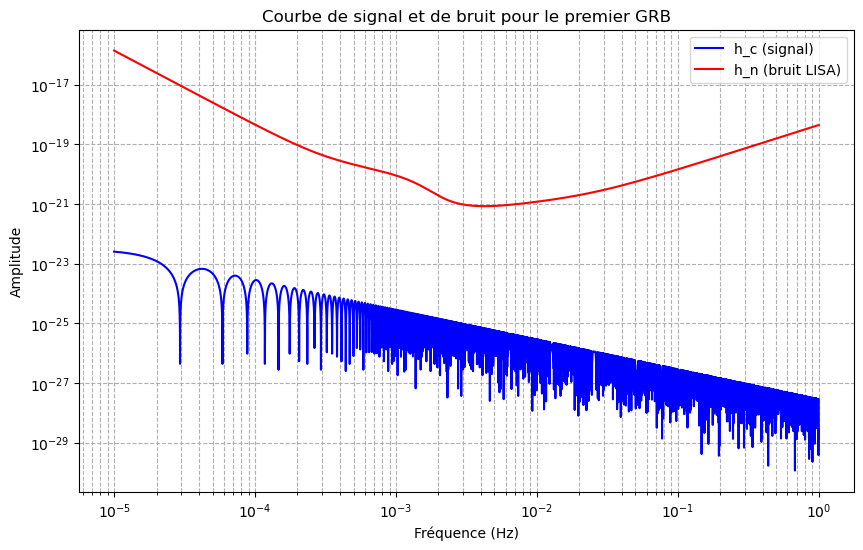

SNR population: 100%|██████████| 10000/10000 [01:26<00:00, 115.43it/s]


In [43]:
samples = generate_population_quasi_mc(10_000, seed=42)
df_snr = compute_population_snr(samples, save_csv='snr_population.csv')

In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
df_snr = pd.read_csv('snr_population.csv')

In [5]:
for param in df_snr.columns:
    print(f"--- Statistiques pour {param} ---")
    print(df_snr[param].describe())
    

--- Statistiques pour E_GRB ---
count    1.000000e+04
mean     4.823542e+53
std      1.475768e+54
min      1.001201e+46
25%      1.779841e+48
50%      3.162518e+50
75%      5.624233e+52
max      9.989506e+54
Name: E_GRB, dtype: float64
--- Statistiques pour T_90 ---
count    10000.000000
mean        58.695723
std        105.983028
min          0.100094
25%          0.840853
50%          7.071239
75%         59.426028
max        499.918380
Name: T_90, dtype: float64
--- Statistiques pour E_aft ---
count    1.000000e+04
mean     7.235049e+54
std      1.758407e+55
min      1.000579e+50
25%      3.162392e+51
50%      9.999978e+52
75%      3.160126e+54
max      9.994425e+55
Name: E_aft, dtype: float64
--- Statistiques pour t_dec ---
count    10000.000000
mean        86.875089
std        189.460065
min          0.010005
25%          0.177900
50%          3.161346
75%         56.238834
max        998.924901
Name: t_dec, dtype: float64
--- Statistiques pour t_jet_break ---
count     10000.0000

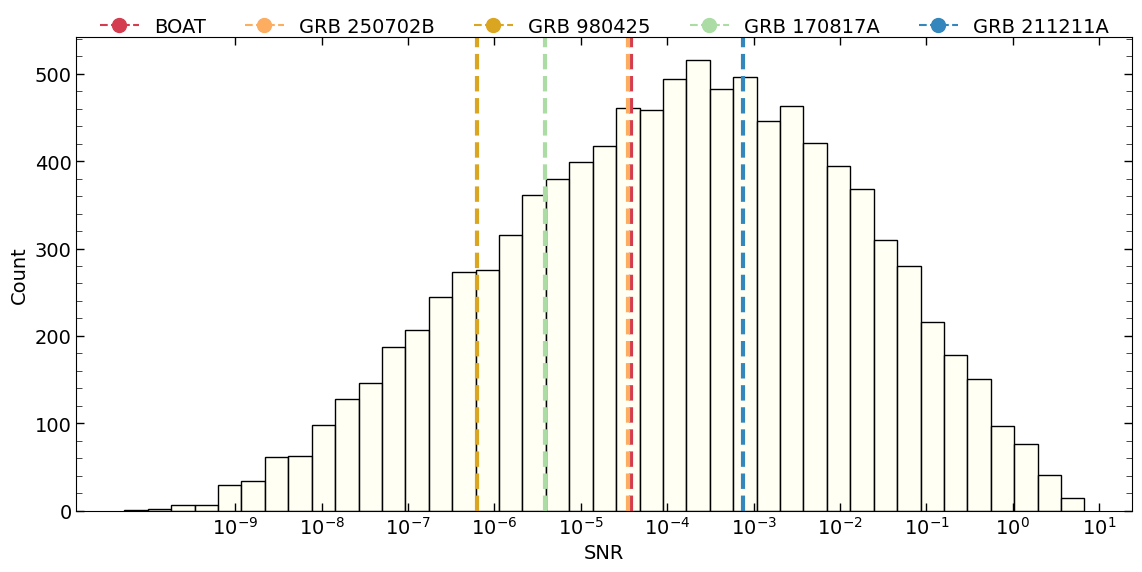

count    1.000000e+04
mean     5.216136e-02
std      2.871911e-01
min      5.201468e-11
25%      4.383209e-06
50%      1.563090e-04
75%      4.025756e-03
max      6.748160e+00
Name: snr, dtype: float64


In [85]:
from matplotlib.lines import Line2D

# plot snr distribution
snr = df_snr['snr']
plt.figure(figsize=(12, 6))
mask = snr > 0
snr_plot = snr[mask]
 
sns.histplot(snr_plot, bins='auto', color='ivory', edgecolor='k', log_scale=(True, False))

cmap_vals = [0.1, 0.3, 0.5, 0.7, 0.9]
colors = [plt.cm.Spectral(x) for x in cmap_vals]
colors[2] = 'goldenrod'

grb_names = ['BOAT', 'GRB 250702B', 'GRB 980425', 'GRB 170817A', 'GRB 211211A']
grb_values = [3.8e-5, 3.5e-5, 6.3e-7, 3.8e-6, 7.5e-4]

handles = []
for name, color in zip(grb_names, colors):
    handles.append(Line2D([0], [0], color=color, marker='o', linestyle='--', markersize=10, label=name))

for val, color in zip(grb_values, colors):
    plt.axvline(val, color=color, linestyle='--', lw=3)
    


plt.xlabel('SNR', fontsize=14)
plt.ylabel('Count', fontsize=14)
plt.xticks(fontsize=14)
# put xticks every power of 10 automatically
plt.xticks(np.logspace(-9, 1, 11))
plt.yticks(fontsize=14)

plt.legend(handles=handles, loc='upper center', bbox_to_anchor=(0.5, 1.08), ncol=len(grb_names), frameon=False, fontsize=14)
plt.tight_layout(rect=[0, 0, 1, 0.97])
plt.show()
print(df_snr['snr'].describe())

/usr/local/lib/python3.11/site-packages/seaborn/distributions.py:413: UserWarning: `bins` cannot be 'auto' when using weights. Setting `bins=10`, but you will likely want to adjust.
  warnings.warn(msg, UserWarning)


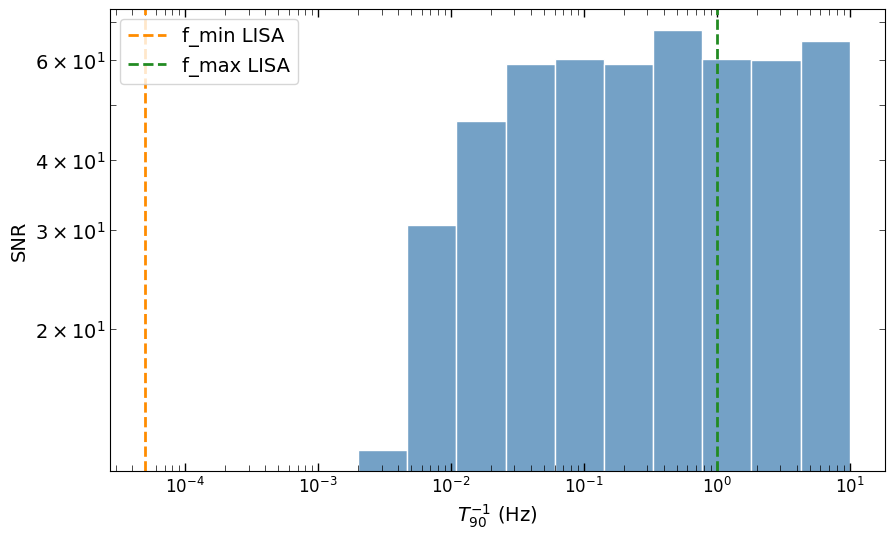

In [27]:
# plot snr vs inv_T90
plt.figure(figsize=(10, 6))
df_snr['inv_T90'] = 1/df_snr['T_90']
sns.histplot(x='inv_T90', weights='snr', data=df_snr, bins='auto', color='steelblue', edgecolor='white', log_scale=(True, False))
min_freq_LISA = (5e-5)  # f_min
max_freq_LISA = 1
plt.axvline(min_freq_LISA, color='darkorange', linestyle='--', label='f_min LISA', lw=2)
plt.axvline(max_freq_LISA, color='forestgreen', linestyle='--', label='f_max LISA', lw=2)
plt.legend(loc = 'best', fontsize=14)
plt.xlabel(r'$T_{90}^{-1}$ (Hz)', fontsize=14)
plt.ylabel('SNR', fontsize=14)
plt.xscale('log')
plt.yscale('log')
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.show()

/usr/local/lib/python3.11/site-packages/seaborn/distributions.py:413: UserWarning: `bins` cannot be 'auto' when using weights. Setting `bins=10`, but you will likely want to adjust.
  warnings.warn(msg, UserWarning)


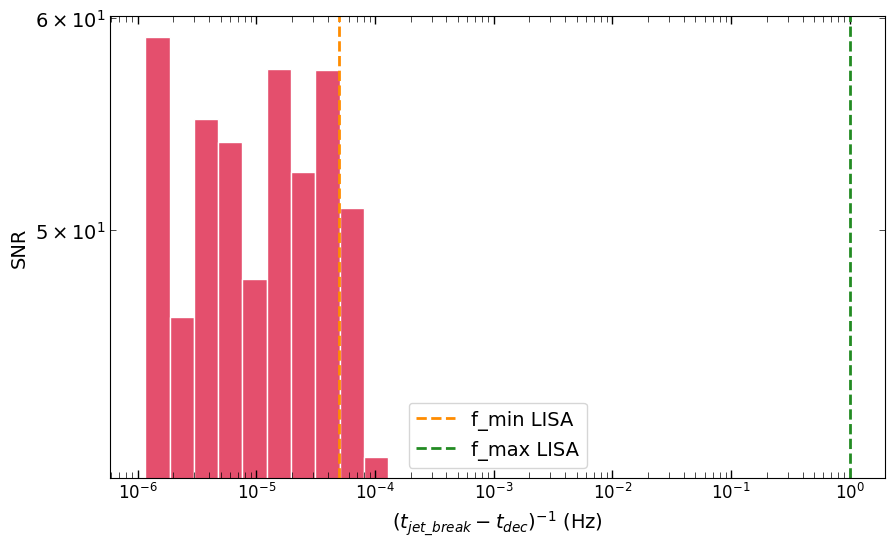

/usr/local/lib/python3.11/site-packages/seaborn/distributions.py:413: UserWarning: `bins` cannot be 'auto' when using weights. Setting `bins=10`, but you will likely want to adjust.
  warnings.warn(msg, UserWarning)


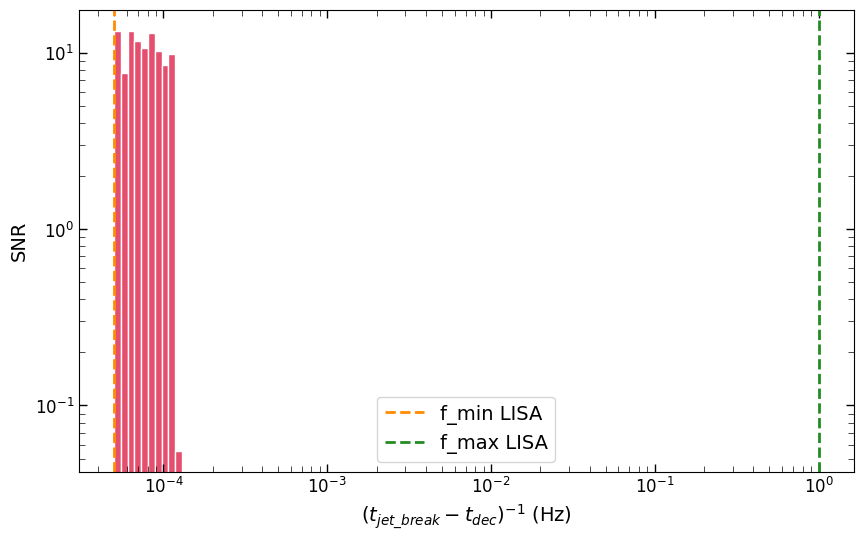

,E_GRB,T_90,E_aft,t_dec,t_jet_break,d,theta,beta,snr,inv_T90,inv_t_diff,t_diff,t_diff_e,t_diff_days
1377,9.476039e+54,0.109039,3.138896e+55,14.678655,19919.018145,4.757445e+07,1.003501,0.913589,5.753362,9.171031,0.000050,19904.339491,1.99e+04,0.230374
6945,5.548110e+54,2.803908,6.345214e+54,273.845840,12041.242558,4.394566e+07,1.162781,0.971287,4.038508,0.356645,0.000085,11767.396718,1.18e+04,0.136197
7905,8.033949e+54,2.173142,2.268905e+54,0.791513,15025.163457,6.022919e+07,1.127913,0.906525,3.621474,0.460163,0.000067,15024.371943,1.50e+04,0.173893
3937,9.799609e+54,0.231965,2.697316e+53,64.954970,11902.429037,1.118714e+08,1.196710,0.987204,2.866078,4.310993,0.000084,11837.474067,1.18e+04,0.137008
961,3.873269e+54,0.411022,3.125770e+54,6.170170,10050.425848,4.091838e+07,1.293741,0.962001,2.724266,2.432962,0.000100,10044.255679,1.00e+04,0.116253
161,6.485398e+54,0.691867,5.540832e+53,0.042425,16178.931977,7.753090e+07,1.029936,0.953702,2.720847,1.445365,0.000062,16178.889552,1.62e+04,0.187256
3678,7.064024e+54,66.137374,4.280928e+52,440.970687,11237.455053,5.790248e+07,1.316248,0.968364,2.619482,0.015120,0.000093,10796.484367,1.08e+04,0.124959
5822,4.931394e+54,11.075149,1.201812e+50,3.182641,12500.776366,6.219887e+07,1.183010,0.964846,2.419323,0.090292,0.000080,12497.593726,1.25e+04,0.144648
5345,8.254867e+54,1.073927,3.380631e+54,0.010066,15751.667352,1.264457e+08,1.058150,0.982588,2.288103,0.931162,0.000063,15751.657286,1.58e+04,0.182311
4385,5.371923e+54,7.042656,1.655558e+54,3.482780,19703.300391,8.690290e+07,1.090832,0.947869,1.908382,0.141992,0.000051,19699.817612,1.97e+04,0.228007


In [36]:
# plot snr vs inv_(t_break - t_dec)
plt.figure(figsize=(10, 6))
df_snr['inv_t_diff'] = 1/(df_snr['t_jet_break'] - df_snr['t_dec'])
# make also one for t_diff
df_snr['t_diff'] = df_snr['t_jet_break'] - df_snr['t_dec']
# make t_diff in days
df_snr['t_diff_days'] = df_snr['t_diff'] / 86400

sns.histplot(x='inv_t_diff', weights='snr', data=df_snr, bins='auto', color='crimson', edgecolor='white', log_scale=(True, False))
min_freq_LISA = (5e-5)  # f_min
max_freq_LISA = 1
plt.axvline(min_freq_LISA, color='darkorange', linestyle='--', label='f_min LISA', lw=2)
plt.axvline(max_freq_LISA, color='forestgreen', linestyle='--', label='f_max LISA', lw=2)
plt.legend(loc = 'best', fontsize=14)
plt.xlabel(r'$(t_{jet\_break} - t_{dec})^{-1}$ (Hz)', fontsize=14)
plt.ylabel('SNR', fontsize=14)
plt.xscale('log')
plt.yscale('log')
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.show()
# See the case where inv_t_diff 
mask = (df_snr['inv_t_diff'] > 5e-5) & (df_snr['inv_t_diff'] < 1)
df_snr_filtered = df_snr[mask]

plt.figure(figsize=(10, 6))
sns.histplot(x='inv_t_diff', weights='snr', data=df_snr_filtered, bins='auto', color='crimson', edgecolor='white', log_scale=(True, False))
min_freq_LISA = (5e-5)  # f_min
max_freq_LISA = 1
plt.axvline(min_freq_LISA, color='darkorange', linestyle='--', label='f_min LISA', lw=2)
plt.axvline(max_freq_LISA, color='forestgreen', linestyle='--', label='f_max LISA', lw=2)
plt.legend(loc = 'best', fontsize=14)
plt.xlabel(r'$(t_{jet\_break} - t_{dec})^{-1}$ (Hz)', fontsize=14)
plt.ylabel('SNR', fontsize=14)
plt.xscale('log')
plt.yscale('log')
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.show()

df_snr_filtered = df_snr_filtered.sort_values(by='snr', ascending=False)
df_snr_filtered.head(20)

In [41]:
# sort by snr 
df_snr_sorted = df_snr.sort_values(by='snr', ascending=False)

# make a new column which is distance in Mpc
df_snr_sorted['d_Mpc'] = df_snr_sorted['d'] / 1e6
# same for theta from rad to deg
df_snr_sorted['theta_deg'] = np.degrees(df_snr_sorted['theta'])

# make a new one for t_jet_break - t_dec in s
df_snr_sorted['t_break_dec_diff'] = df_snr_sorted['t_jet_break'] - df_snr_sorted['t_dec']

# then compute the inverse of the new t_break_dec_diff and T90 to see if they are correlated with snr
df_snr_sorted['inv_t_break_dec_diff'] = 1 / df_snr_sorted['t_break_dec_diff']
df_snr_sorted['inv_T90'] = 1 / df_snr_sorted['T_90']

# count how many have snr > 5
snr_threshold = 3
count_above_threshold = (df_snr_sorted['snr'] > snr_threshold).sum()
print(f"Nombre de GRBs avec SNR > {snr_threshold}: {count_above_threshold} sur {len(df_snr_sorted)}")
# save the top 10 in a csv
df_snr_sorted.head(25).to_csv('top10_snr_population.csv', index=False)

df_snr_sorted.head(25)

Nombre de GRBs avec SNR > 3: 23 sur 10000


,E_GRB,T_90,E_aft,t_dec,t_jet_break,d,theta,beta,snr,inv_T90,inv_t_diff,t_diff,t_diff_e,t_diff_days,d_Mpc,theta_deg,t_break_dec_diff,inv_t_break_dec_diff
9057,9.844326e+54,3.278111,6.988256e+50,88.204938,32623.930402,4.134706e+07,1.380199,0.983665,6.748160,0.305054,0.000031,32535.725464,3.25e+04,0.376571,41.347056,79.079586,32535.725464,0.000031
1377,9.476039e+54,0.109039,3.138896e+55,14.678655,19919.018145,4.757445e+07,1.003501,0.913589,5.753362,9.171031,0.000050,19904.339491,1.99e+04,0.230374,47.574446,57.496392,19904.339491,0.000050
5729,8.933935e+54,1.977608,1.293444e+52,10.513015,113789.446608,4.861714e+07,1.192843,0.940726,5.325828,0.505661,0.000009,113778.933592,1.14e+05,1.316886,48.617137,68.344894,113778.933592,0.000009
8161,7.416176e+54,0.291459,2.099018e+51,0.018478,320495.846249,4.310916e+07,1.055440,0.937188,5.265637,3.431011,0.000003,320495.827771,3.20e+05,3.709442,43.109162,60.472233,320495.827771,0.000003
3297,8.170165e+54,5.995937,1.623064e+53,0.109408,58158.017270,4.219295e+07,1.245832,0.917015,5.089398,0.166780,0.000017,58157.907861,5.82e+04,0.673124,42.192949,71.380888,58157.907861,0.000017
2081,5.891163e+54,0.816706,8.266789e+52,195.031955,217524.970318,4.490681e+07,1.102759,0.996238,4.664875,1.224431,0.000005,217329.938363,2.17e+05,2.515393,44.906813,63.183429,217329.938363,0.000005
6302,9.633050e+54,20.946994,1.833856e+54,0.508710,162312.359153,4.602961e+07,1.507112,0.932703,4.514188,0.047740,0.000006,162311.850443,1.62e+05,1.878609,46.029615,86.351183,162311.850443,0.000006
417,7.025491e+54,1.045578,5.055529e+50,0.314973,705822.819992,5.549742e+07,1.139585,0.999691,4.441499,0.956409,0.000001,705822.505019,7.06e+05,8.169242,55.497420,65.293407,705822.505019,0.000001
6945,5.548110e+54,2.803908,6.345214e+54,273.845840,12041.242558,4.394566e+07,1.162781,0.971287,4.038508,0.356645,0.000085,11767.396718,1.18e+04,0.136197,43.945665,66.622471,11767.396718,0.000085
5985,9.696707e+54,0.343648,1.406445e+55,641.635496,43090.998919,6.790760e+07,1.106487,0.909082,3.941202,2.909956,0.000024,42449.363424,4.24e+04,0.491312,67.907597,63.397050,42449.363424,0.000024


<Figure size 800x600 with 0 Axes>

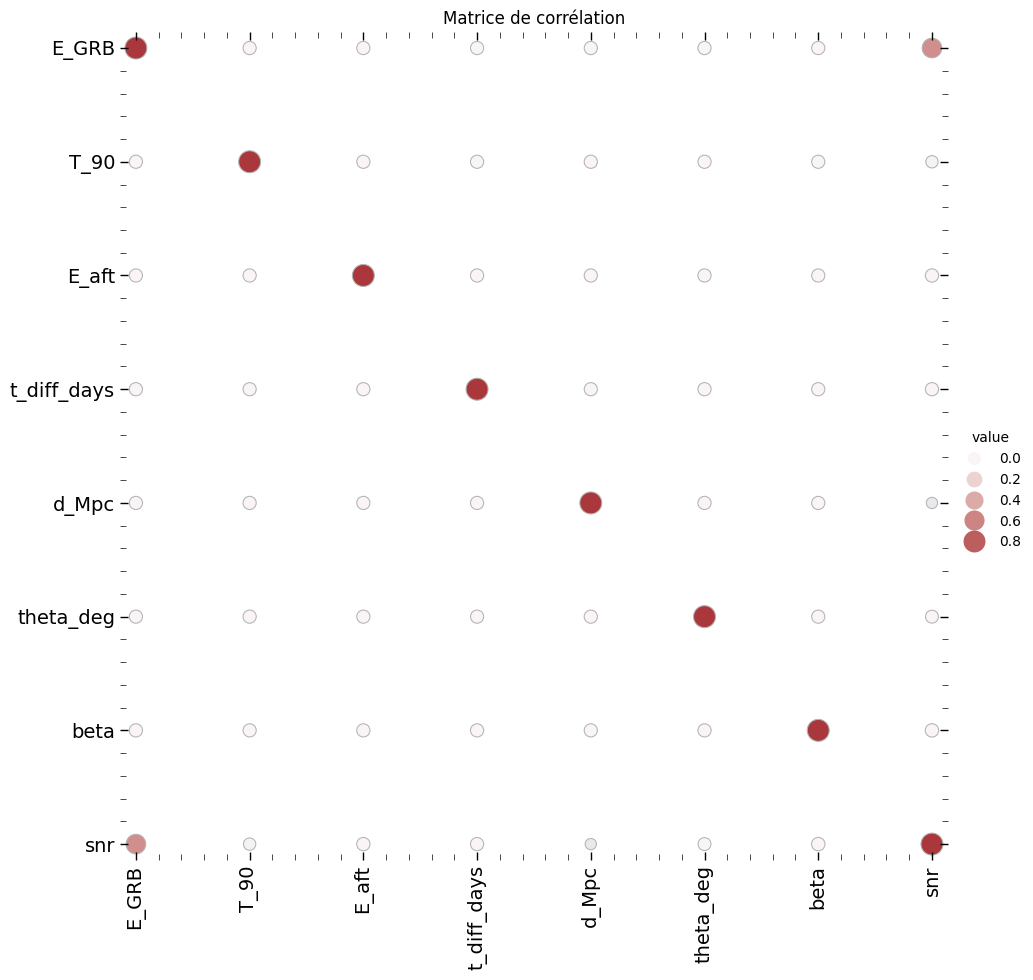

In [42]:
corr = df_snr_sorted[['E_GRB', 'T_90', 'E_aft', 't_diff_days', 'd_Mpc', 'theta_deg', 'beta', 'snr']].corr()
plt.figure(figsize=(8,6))
# Draw each cell as a scatter point with varying size and color
corr_melt = corr.reset_index().melt(id_vars='index')
g = sns.relplot(
    data=corr_melt,
    x="index", y="variable", hue="value", size="value",
    palette="vlag", hue_norm=(-1, 1), edgecolor=".7",
    height=10, sizes=(50, 250), size_norm=(-.2, .8),
)
g.set(xlabel="", ylabel="", aspect="equal")
g.despine(left=True, bottom=True)
g.ax.margins(.02)
for label in g.ax.get_xticklabels():
    label.set_rotation(90)
plt.title("Matrice de corrélation")
plt.show()

/tmp/ipykernel_1352/3134433829.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=corrs.index, y=corrs.values, palette='seismic_r')


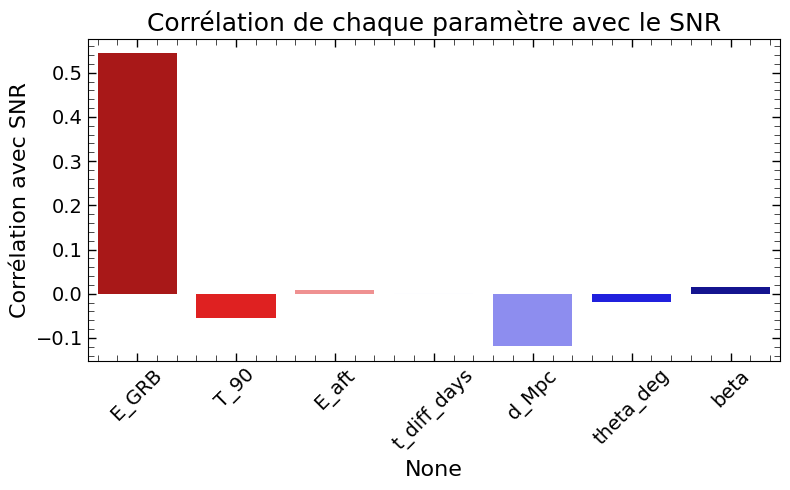

In [44]:
import matplotlib.pyplot as plt
import seaborn as sns

params = ['E_GRB', 'T_90', 'E_aft', 't_diff_days', 'd_Mpc', 'theta_deg', 'beta']
corrs = df_snr_sorted[params + ['snr']].corr()['snr'].drop('snr')

plt.figure(figsize=(8, 5))
sns.barplot(x=corrs.index, y=corrs.values, palette='seismic_r')
plt.xticks(rotation=45, fontsize=14)
plt.yticks(fontsize=14)
plt.ylabel("Corrélation avec SNR", fontsize=16)
plt.title("Corrélation de chaque paramètre avec le SNR", fontsize=18)
plt.tight_layout()
plt.show()

/tmp/ipykernel_1352/2570226210.py:24: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=corrs_sorted.values, y=yticklabels_latex, palette=colors, edgecolor='black')


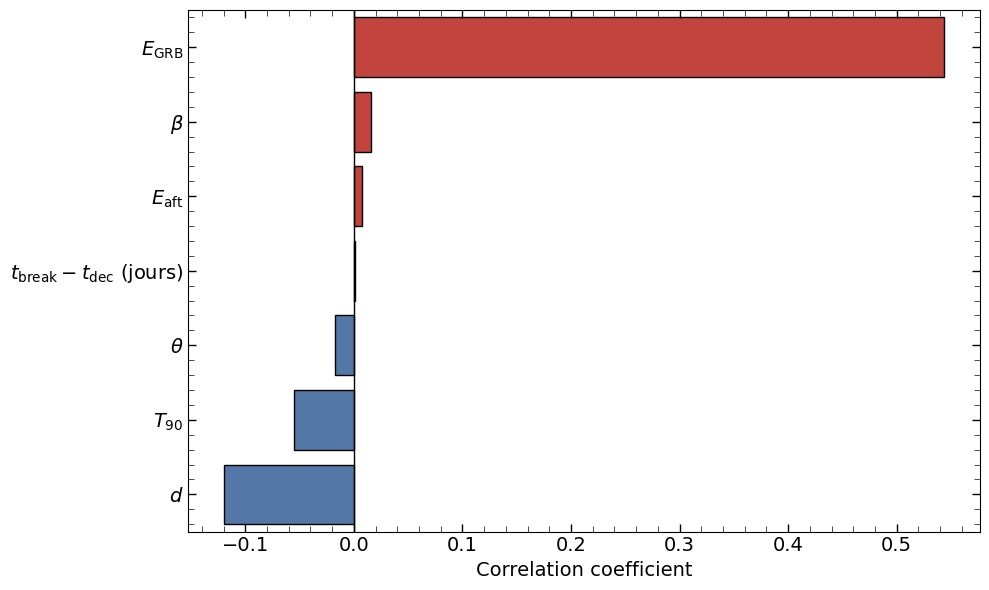

E_GRB          0.543625
beta           0.015382
E_aft          0.007461
t_diff_days    0.001339
theta_deg     -0.017798
T_90          -0.055571
d_Mpc         -0.119306
Name: snr, dtype: float64

In [45]:
# Préparation des données triées par valeur absolue
# Dictionnaire de correspondance
latex_labels = {
    'E_GRB': r'$E_{\mathrm{GRB}}$',
    'T_90': r'$T_{90}$',
    'E_aft': r'$E_{\mathrm{aft}}$',
    't_diff_days': r'$t_{\mathrm{break}} - t_{\mathrm{dec}}$ (jours)',
    'd_Mpc': r'$d$',
    'theta_deg': r'$\theta$',
    'beta': r'$\beta$'
}


corrs_sorted = corrs.sort_values(ascending=False)

# Applique la correspondance
yticklabels_latex = [latex_labels.get(lab, lab) for lab in corrs_sorted.index]


plt.figure(figsize=(10, 6))
# On utilise une palette divergente centrée sur 0
colors = ['#d73027' if x > 0 else '#4575b4' for x in corrs_sorted.values]

sns.barplot(x=corrs_sorted.values, y=yticklabels_latex, palette=colors, edgecolor='black')

plt.axvline(0, color='black', linewidth=1) # Ligne centrale

plt.xlabel("Correlation coefficient", fontsize=14)
plt.ylabel('')
plt.tight_layout()
plt.yticks(fontsize=14)
plt.xticks(fontsize=14)
plt.show()
corrs_sorted

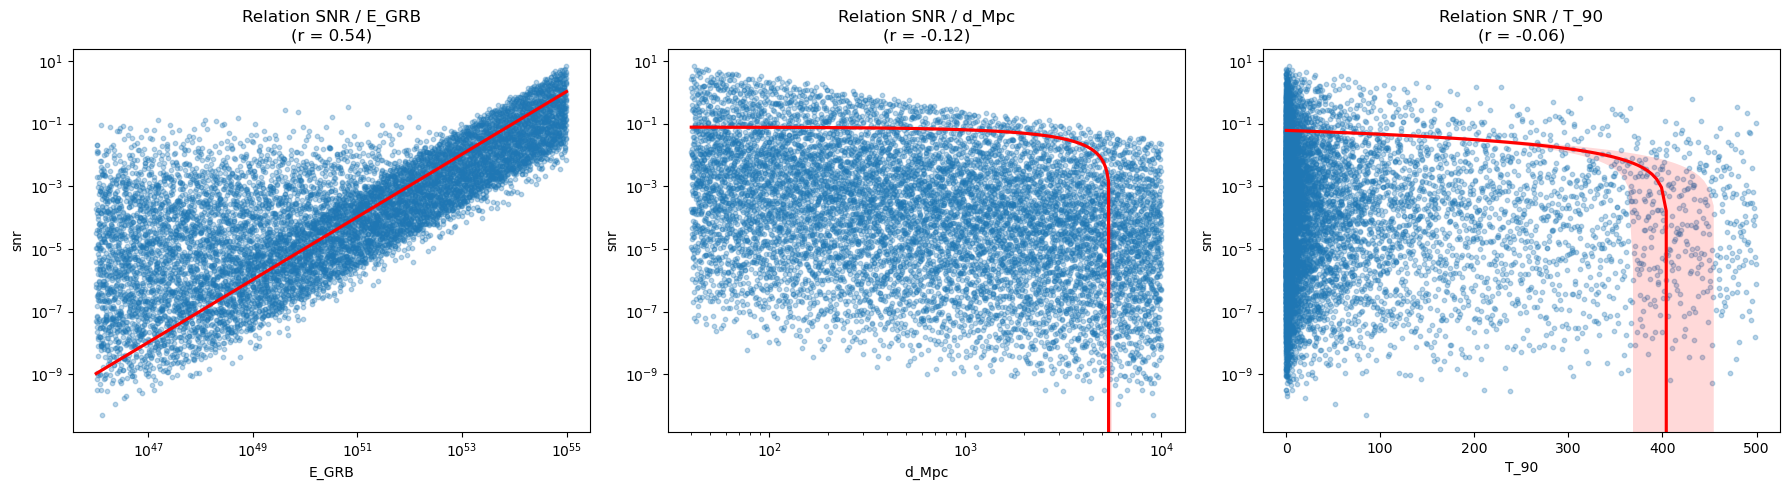

In [83]:
# Sélection des 3 paramètres les plus corrélés (en abs)
top_3 = corrs.abs().sort_values(ascending=False).head(3).index
xscale = 'log'  # ou 'linear' selon le paramètre
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for i, param in enumerate(top_3):
    sns.regplot(data=df_snr_sorted, x=param, y='snr', ax=axes[i], 
                scatter_kws={'alpha':0.3, 's':10}, line_kws={'color':'red'})
    axes[i].set_title(f"Relation SNR / {param}\n(r = {corrs[param]:.2f})")
    if xscale == 'log' and param in ['E_GRB', 'E_aft', 'd_Mpc']: # Exemple de gestion log
        axes[i].set_xscale('log')
    axes[i].set_yscale('log')

plt.tight_layout()
plt.show()

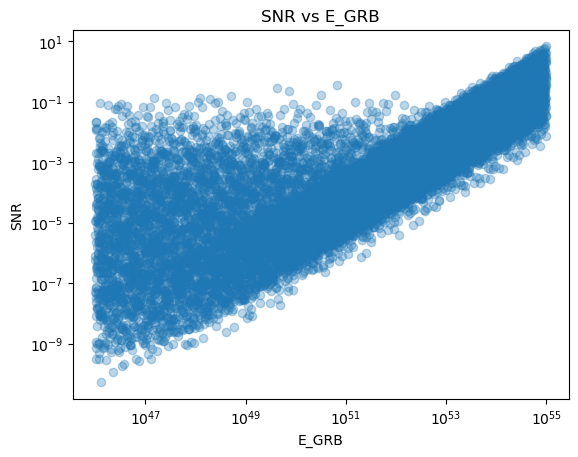

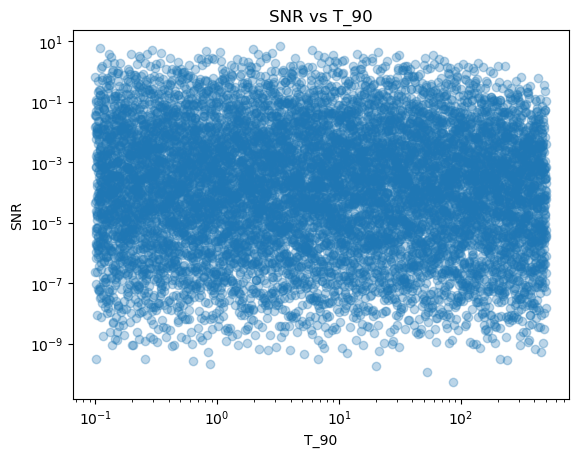

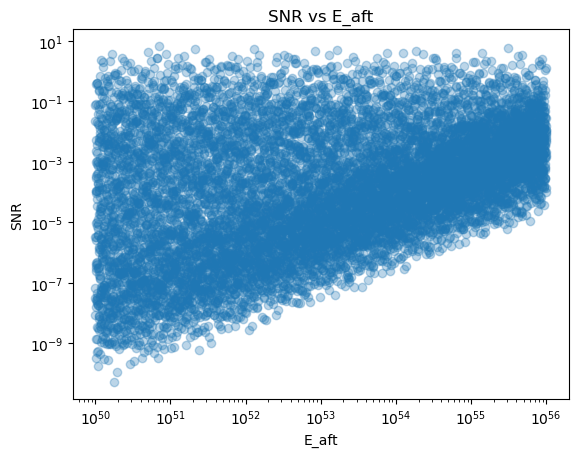

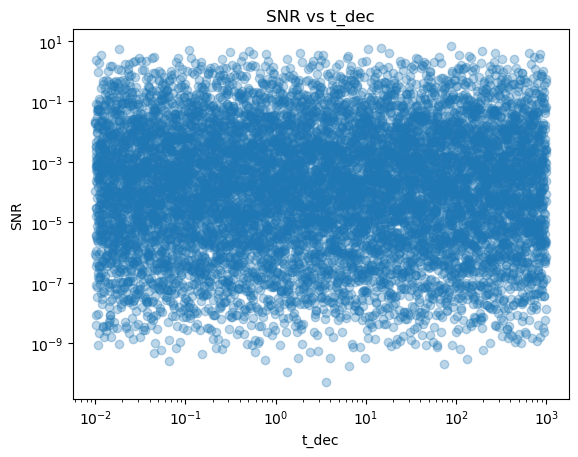

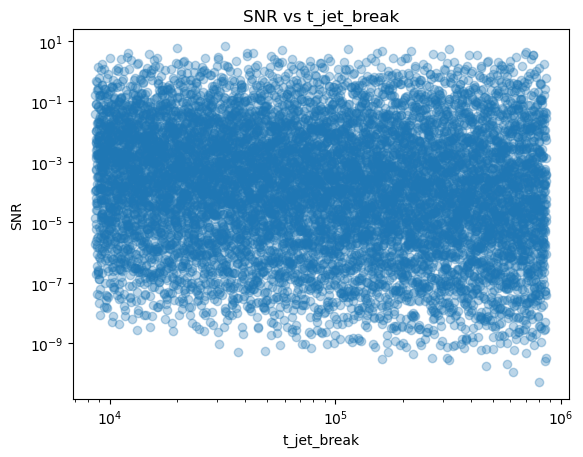

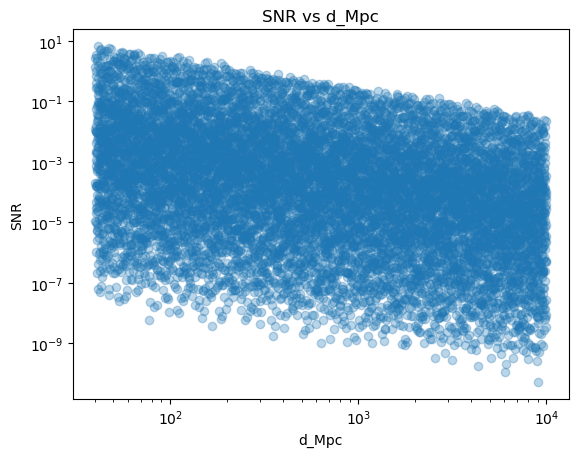

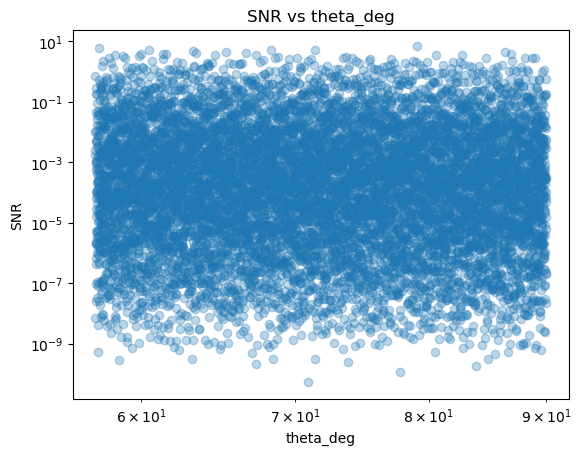

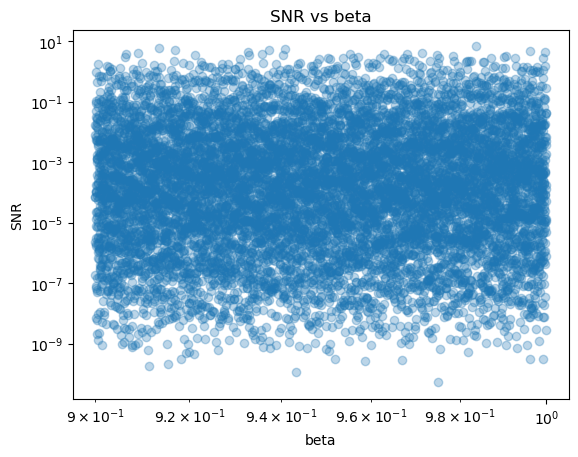

In [72]:
for param in params:
    plt.figure()
    plt.scatter(df_snr_sorted[param], df_snr_sorted['snr'], alpha=0.3)
    plt.xscale('log')
    plt.yscale('log')
    plt.xlabel(param)
    plt.ylabel('SNR')
    plt.title(f'SNR vs {param}')
    plt.show()

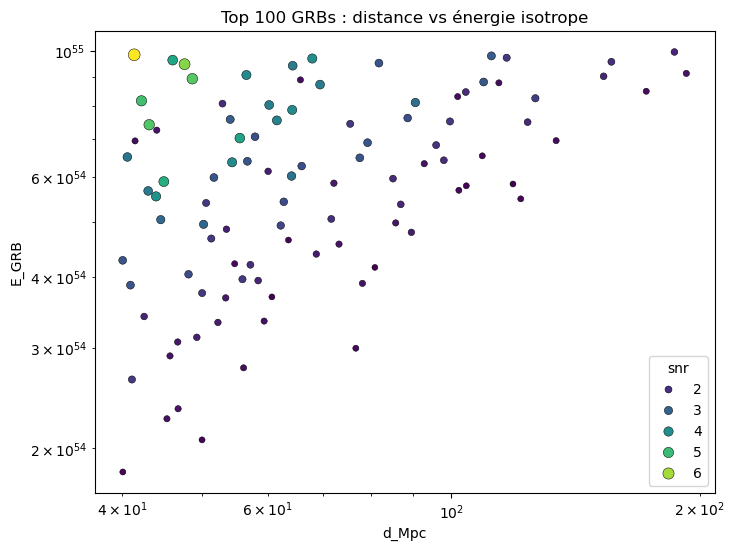

In [66]:
# distribution des 100 meilleurs en fonction de d_mpc vs E_grb
plt.figure(figsize=(8, 6))
sns.scatterplot(data=df_snr_sorted.head(100), x='d_Mpc', y='E_GRB', hue='snr', palette='viridis', edgecolor='black', size = 'snr')
plt.xscale('log')
plt.yscale('log')
plt.title('Top 100 GRBs : distance vs énergie isotrope')
plt.show()